# Clustering HDB resale transactions

**Goal:** apply K-means (random init), K-means++, DBSCAN and HDBSCAN to HDB resale sales, choose their
parameters from evidence, and explain where each method succeeds or fails. This notebook is Stage 3 of
`../AGENTS.md`.

**Input:** decisions from `notebooks/eda.ipynb`, section 17: sales from Jan 2017 to Jun 2026 (sales without a
price index value dropped), four features (floor area, remaining lease in years, storey band midpoint,
index-adjusted price), standardized. A random sample of 20,000 sales (seed 0) keeps silhouette and the density
methods fast; EDA section 13 found no drift across years that would call for stratified sampling.

**Two versions of the data.** EDA section 10 found that 77.7% of sales share their exact floor area, lease and
storey with another sale. Every method runs on the data as recorded ("real") and density methods also run on
"jittered" data, where each value is spread uniformly within its recording step (`jitter_ties`: storey ±1.5,
floor area ±0.5 m², lease ±0.5 month). Differences between the two show what the ties alone produce.

**Terms**

| Term | Meaning |
|---|---|
| sale | One resale transaction, clustered by its four standardized features |
| tie | Sales with identical feature values |
| noise | Sales that DBSCAN or HDBSCAN leave out of every cluster (label -1) |
| silhouette | For each clustered sale: how much closer it is to its own cluster than to the next one, from -1 to 1. Computed on non-noise sales (a random 5,000 of them) |
| Davies-Bouldin | Average ratio of cluster spread to distance between cluster centres; lower is better |
| inertia | K-means objective: total squared distance from each sale to its cluster centre |
| ARI | Adjusted Rand index: agreement between two labellings, 0 for chance and 1 for identical. Noise counts as its own group |
| NMI | Normalized mutual information: shared information between two labellings, 0 to 1 |
| shuffled null | The same data with each feature column shuffled independently: same distributions, no joint pattern |
| floor-area baseline | K-means on floor area alone, to show how much of the match with flat type floor area explains |

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

from hdb.features import SCREENING_FEATURES, jitter_ties, load_price_index, load_resale, screening_features, standardize
from hdb.methods import dbscan, hdbscan, kmeans_plus_plus, kmeans_random
from hdb.metrics import best_density_setting, evaluate, k_distances, knee_distance, pairwise_ari, timed_fit_predict
from hdb.paths import figures_dir, results_dir
from hdb.screening import NOISE_LABEL, shuffled_null, single_value_share

%matplotlib inline
pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

SEED = 0
SAMPLE_SIZE = 20_000
SILHOUETTE_SAMPLE = 5_000
RESULTS, FIGURES = results_dir(), figures_dir()

## 1. Data and features

In [2]:
resale = load_resale()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    all_features = screening_features(resale, load_price_index())
for warning in caught:
    print("warning:", warning.message)

sample = all_features.sample(n=SAMPLE_SIZE, random_state=SEED)
sales = resale.loc[sample.index]
X = standardize(sample)
X_jitter = standardize(jitter_ties(sample, np.random.default_rng(SEED)))
DATA = {"real": X, "jittered": X_jitter}
flat_type = sales["flat_type"].to_numpy()
storey_band = sales["storey_range"].to_numpy()

print(f"{len(all_features)} sales with features; sample of {len(sample)}")
print("distinct rows, real:", len(np.unique(X, axis=0)), "| jittered:", len(np.unique(X_jitter, axis=0)))
print("sale years in sample:", sales["month"].str[:4].value_counts().sort_index().to_dict())
sample.describe().T

234294 sales with features; sample of 20000
distinct rows, real: 19989 | jittered: 20000
sale years in sample: {'2017': 1721, '2018': 1802, '2019': 1906, '2020': 1931, '2021': 2506, '2022': 2253, '2023': 2222, '2024': 2457, '2025': 2156, '2026': 1046}


,count,mean,std,min,25%,50%,75%,max
floor_area_sqm,20000.0,96.538,24.111,31.000,76.000,93.000,112.000,2.490e+02
remaining_lease_years,20000.0,73.832,14.351,39.667,61.917,73.333,88.333,9.733e+01
storey_mid,20000.0,8.787,5.954,2.000,5.000,8.000,11.000,4.700e+01
real_price,20000.0,666399.340,218278.976,231330.798,511260.504,630793.157,778356.654,1.905e+06


**Observations**

- 234,294 sales have features; the sample holds 20,000, with 1,046 (2026) to 2,506 (2021) per year.
- On real data 19,989 of 20,000 rows are distinct: adjusted price differs between sales even when floor area, lease and storey are tied, so exact duplicates are rare. Ties still sit very close together in the other three dimensions.
- Standardized features have the ranges of the raw ones: floor area 31 to 249 m², lease 39.7 to 97.3 years, storey 2 to 47, adjusted price S$231,331 to S$1,905,000.

## 2. K-means: choosing K

K = 2 to 12 with `n_init=10`. For each K: inertia (elbow), silhouette on real data and on one shuffled null,
Davies-Bouldin, and ARI and NMI against flat type next to the floor-area baseline with the same K.

In [3]:
null_X = shuffled_null(X, np.random.default_rng(SEED))
area_only = X[:, [SCREENING_FEATURES.index("floor_area_sqm")]]
rows = []
for k in range(2, 13):
    model = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels, seconds = timed_fit_predict(model, X)
    scores = evaluate(X, labels, truth=flat_type, silhouette_sample=SILHOUETTE_SAMPLE, seed=SEED)
    null_labels = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(null_X)
    area_labels = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(area_only)
    rows.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": scores["silhouette"],
            "null_silhouette": silhouette_score(null_X, null_labels, sample_size=SILHOUETTE_SAMPLE, random_state=SEED),
            "davies_bouldin": scores["davies_bouldin"],
            "ari_flat_type": scores["ari"],
            "nmi_flat_type": scores["nmi"],
            "ari_floor_area_only": adjusted_rand_score(flat_type, area_labels),
            "seconds": seconds,
        }
    )
k_sweep = pd.DataFrame(rows).assign(ratio=lambda d: d["silhouette"] / d["null_silhouette"])
k_sweep.to_csv(RESULTS / "kmeans_k_sweep.csv", index=False)
k_sweep

,k,inertia,silhouette,null_silhouette,davies_bouldin,ari_flat_type,nmi_flat_type,ari_floor_area_only,seconds,ratio
0,2,54551.194,0.284,0.203,1.269,0.191,0.296,0.283,0.100,1.399
1,3,42549.278,0.294,0.208,1.269,0.212,0.305,0.650,0.050,1.415
2,4,33590.493,0.317,0.219,1.115,0.214,0.294,0.649,0.078,1.448
3,5,28754.922,0.285,0.214,1.146,0.243,0.343,0.582,0.092,1.333
4,6,25692.767,0.280,0.197,1.173,0.233,0.338,0.598,0.107,1.423
5,7,23527.923,0.300,0.193,1.091,0.256,0.384,0.631,0.111,1.553
6,8,21653.443,0.282,0.191,1.134,0.242,0.373,0.628,0.131,1.476
7,9,20224.490,0.259,0.194,1.218,0.198,0.357,0.566,0.126,1.333
8,10,18777.286,0.257,0.191,1.167,0.189,0.352,0.511,0.162,1.344
9,11,17594.793,0.250,0.190,1.144,0.220,0.392,0.502,0.134,1.315


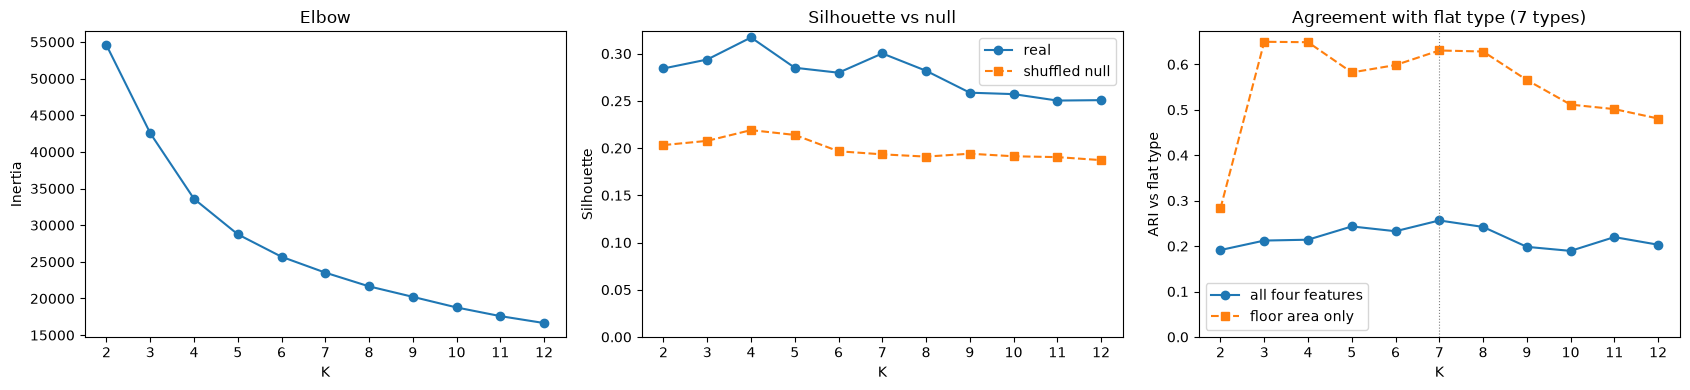

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(k_sweep["k"], k_sweep["inertia"], "o-")
axes[0].set(xlabel="K", ylabel="Inertia", title="Elbow")
axes[1].plot(k_sweep["k"], k_sweep["silhouette"], "o-", label="real")
axes[1].plot(k_sweep["k"], k_sweep["null_silhouette"], "s--", label="shuffled null")
axes[1].set(xlabel="K", ylabel="Silhouette", title="Silhouette vs null", ylim=(0, None))
axes[1].legend()
axes[2].plot(k_sweep["k"], k_sweep["ari_flat_type"], "o-", label="all four features")
axes[2].plot(k_sweep["k"], k_sweep["ari_floor_area_only"], "s--", label="floor area only")
axes[2].axvline(7, color="grey", lw=0.8, ls=":")
axes[2].set(xlabel="K", ylabel="ARI vs flat type", title="Agreement with flat type (7 types)", ylim=(0, None))
axes[2].legend()
for ax in axes:
    ax.set_xticks(k_sweep["k"])
fig.tight_layout()
fig.savefig(FIGURES / "kmeans_k_sweep.png", dpi=150)

**Observations**

- **Silhouette peaks at K=4** (0.317 vs null 0.219, ratio 1.45); K=7 is a second, lower peak (0.300). Above K=8 the silhouette falls to 0.25 to 0.26. The ratio to the null stays between 1.32 and 1.55 for every K, below the 2x screening rule.
- **The elbow has no clear bend:** inertia falls from 54,551 (K=2) to 33,590 (K=4) and then declines gradually to 16,649 (K=12). The largest drop in slope is at K=4, so elbow and silhouette agree loosely.
- Davies-Bouldin is lowest at K=7 (1.091) and close at K=4 (1.115).
- **ARI against flat type never exceeds 0.256** (K=7, the number of flat types). K-means on floor area alone reaches 0.649 at K=4 and 0.631 at K=7: one feature matches flat type about 2.5 to 3 times better than all four.

**Decision:** K=4, the silhouette peak, where the elbow bends most. K=7 is not chosen for its match with flat type: that match is better explained by floor area alone.

In [5]:
K = 4

## 3. K-means: initialization ablation (random vs K-means++)

At the chosen K, 20 seeds each with `n_init=1`. Gap to best is the inertia above the lowest inertia found by any
of the 40 runs.

In [6]:
rows, runs = [], {}
for name, factory in [("random", kmeans_random), ("k-means++", kmeans_plus_plus)]:
    runs[name] = []
    for seed in range(20):
        model = factory(K, seed)
        labels, seconds = timed_fit_predict(model, X)
        runs[name].append(labels)
        rows.append({"init": name, "seed": seed, "inertia": model.inertia_, "n_iter": model.n_iter_, "seconds": seconds, "ari_flat_type": adjusted_rand_score(flat_type, labels)})
init_runs = pd.DataFrame(rows)
init_runs["gap_to_best_%"] = 100 * (init_runs["inertia"] / init_runs["inertia"].min() - 1)
init_runs.to_csv(RESULTS / "kmeans_init_ablation.csv", index=False)

stability = {name: pairwise_ari(labels) for name, labels in runs.items()}
init_summary = init_runs.groupby("init").agg(
    mean_gap_pct=("gap_to_best_%", "mean"),
    worst_gap_pct=("gap_to_best_%", "max"),
    runs_within_0_1_pct=("gap_to_best_%", lambda g: int((g <= 0.1).sum())),
    median_iterations=("n_iter", "median"),
    max_iterations=("n_iter", "max"),
    mean_seconds=("seconds", "mean"),
)
init_summary["median_pairwise_ari"] = [np.median(stability[name]) for name in init_summary.index]
init_summary["min_pairwise_ari"] = [stability[name].min() for name in init_summary.index]
init_summary

,mean_gap_pct,worst_gap_pct,runs_within_0_1_pct,median_iterations,max_iterations,mean_seconds,median_pairwise_ari,min_pairwise_ari
init,,,,,,,,
k-means++,0.006,0.009,20,20.0,38,0.008,0.961,0.932
random,0.006,0.009,20,24.0,34,0.008,0.955,0.931


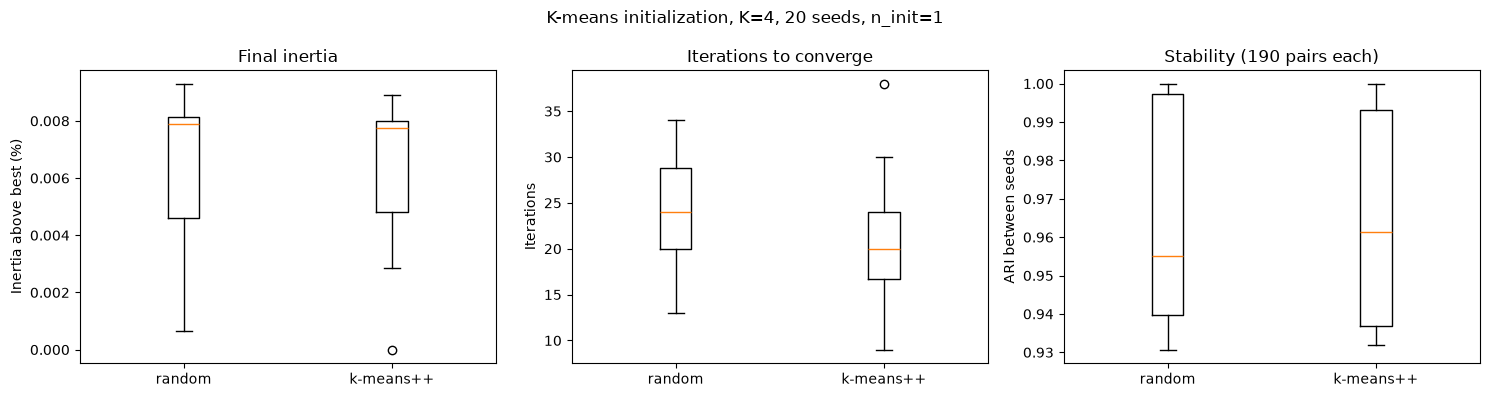

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = list(runs)
axes[0].boxplot([init_runs.loc[init_runs["init"] == n, "gap_to_best_%"] for n in names])
axes[0].set(ylabel="Inertia above best (%)", title="Final inertia")
axes[1].boxplot([init_runs.loc[init_runs["init"] == n, "n_iter"] for n in names])
axes[1].set(ylabel="Iterations", title="Iterations to converge")
axes[2].boxplot([stability[n] for n in names])
axes[2].set(ylabel="ARI between seeds", title="Stability (190 pairs each)")
for ax in axes:
    ax.set_xticks([1, 2], names)
fig.suptitle(f"K-means initialization, K={K}, 20 seeds, n_init=1")
fig.tight_layout()
fig.savefig(FIGURES / "kmeans_init_ablation.png", dpi=150)

**Observations**

- Both initializations reach the same optimum: every one of the 40 runs is within 0.1% of the best inertia (the worst gap is 0.009% for both), so initialization makes no measurable difference at K=4.
- K-means++ needs fewer iterations (median 20 vs 24), but runs take about 0.01 s either way.
- Seeds agree with ARI 0.93 to 1.00 (median 0.955 random, 0.961 K-means++). Partitions that differ in about 5% of assignments have inertia within 0.01% of each other: the objective is flat near the optimum, which fits weak separation between clusters (silhouette 1.45x the null).

## 4. K-means: sensitivity to preprocessing

One change at a time from the default (standardized four features), K fixed, `n_init=10`. Silhouette is computed
in each variant's own feature space, so it compares partitions only loosely; ARI against the default labels and
against flat type compare them directly.

In [8]:
def without(column):
    return standardize(sample.drop(columns=column))


variants = {
    "default (standardized)": X,
    "raw units": sample.to_numpy(),
    "jittered": X_jitter,
    "without price": without("real_price"),
    "without storey": without("storey_mid"),
    "without floor area": without("floor_area_sqm"),
    "without lease": without("remaining_lease_years"),
}
variant_labels = {name: KMeans(n_clusters=K, n_init=10, random_state=SEED).fit_predict(data) for name, data in variants.items()}
sensitivity = pd.DataFrame(
    [
        {
            "variant": name,
            "silhouette (own space)": evaluate(variants[name], labels, silhouette_sample=SILHOUETTE_SAMPLE, seed=SEED)["silhouette"],
            "ari_vs_default": adjusted_rand_score(variant_labels["default (standardized)"], labels),
            "ari_flat_type": adjusted_rand_score(flat_type, labels),
        }
        for name, labels in variant_labels.items()
    ]
)
sensitivity.to_csv(RESULTS / "kmeans_sensitivity.csv", index=False)
sensitivity

,variant,silhouette (own space),ari_vs_default,ari_flat_type
0,default (standardized),0.317,1.000,0.214
1,raw units,0.540,0.261,0.229
2,jittered,0.316,0.942,0.218
3,without price,0.357,0.640,0.192
4,without storey,0.373,0.490,0.256
5,without floor area,0.341,0.662,0.135
6,without lease,0.317,0.337,0.461


**Observations**

- **Raw units** give the highest silhouette (0.540) but share little with the default partition (ARI 0.261): on raw units the clusters are price bands (Stage 0, `results/screening_roles.csv`). A higher silhouette in a different feature space is not a better clustering.
- Jitter changes little for K-means (ARI 0.942 with the default).
- Every feature changes the partition when removed: ARI with the default is 0.337 without lease, 0.490 without storey, 0.640 without price and 0.662 without floor area.
- **Removing lease doubles the match with flat type** (ARI 0.461 vs 0.214): lease splits flats of the same type into old and new, which cuts across flat type. Removing floor area lowers it to 0.135.

## 5. K-means: what the clusters contain

In [9]:
def relabel_by_size(labels):
    labels = np.asarray(labels)
    clusters, counts = np.unique(labels[labels != NOISE_LABEL], return_counts=True)
    mapping = {old: new for new, old in enumerate(clusters[np.argsort(-counts, kind="stable")])}
    return np.array([mapping.get(label, NOISE_LABEL) for label in labels])


def top_value(values):
    counts = values.value_counts(normalize=True)
    return f"{counts.index[0]} ({counts.iloc[0]:.0%})"


def cluster_profiles(labels):
    frame = sample.assign(
        cluster=labels,
        nominal_price=sales["resale_price"].to_numpy(),
        flat_type=flat_type,
        flat_model=sales["flat_model"].to_numpy(),
        town=sales["town"].to_numpy(),
        storey_range=storey_band,
    )
    grouped = frame.groupby("cluster")
    profiles = grouped[SCREENING_FEATURES].median()
    profiles.insert(0, "share", grouped.size() / len(frame))
    profiles.insert(0, "sales", grouped.size())
    for column in ["flat_type", "flat_model", "town", "storey_range"]:
        profiles[f"top {column}"] = grouped[column].agg(top_value)
    return profiles


kmeans_labels = relabel_by_size(KMeans(n_clusters=K, n_init=10, random_state=SEED).fit_predict(X))
kmeans_profile = cluster_profiles(kmeans_labels)
kmeans_profile.to_csv(RESULTS / "kmeans_profiles.csv")
kmeans_profile

,sales,share,floor_area_sqm,remaining_lease_years,storey_mid,real_price,top flat_type,top flat_model,top town,top storey_range
cluster,,,,,,,,,,
0,7047,0.352,93.0,90.250,8.0,632468.334,4 ROOM (62%),Model A (58%),PUNGGOL (18%),10 TO 12 (22%)
1,6357,0.318,73.0,59.583,5.0,469494.412,3 ROOM (61%),New Generation (38%),BEDOK (10%),04 TO 06 (28%)
2,4900,0.245,122.0,69.833,8.0,781035.857,5 ROOM (53%),Improved (39%),TAMPINES (13%),04 TO 06 (27%)
3,1696,0.085,95.0,89.875,20.0,996948.954,4 ROOM (52%),Model A (46%),BUKIT MERAH (15%),16 TO 18 (21%)


In [10]:
pd.crosstab(kmeans_labels, flat_type, normalize="index").round(2)

col_0,1 ROOM,2 ROOM,3 ROOM,4 ROOM,5 ROOM,EXECUTIVE,MULTI-GENERATION
row_0,,,,,,,
0,0.0,0.04,0.12,0.62,0.22,0.00,0.0
1,0.0,0.02,0.61,0.37,0.00,0.00,0.0
2,0.0,0.00,0.00,0.18,0.53,0.28,0.0
3,0.0,0.00,0.07,0.52,0.38,0.02,0.0


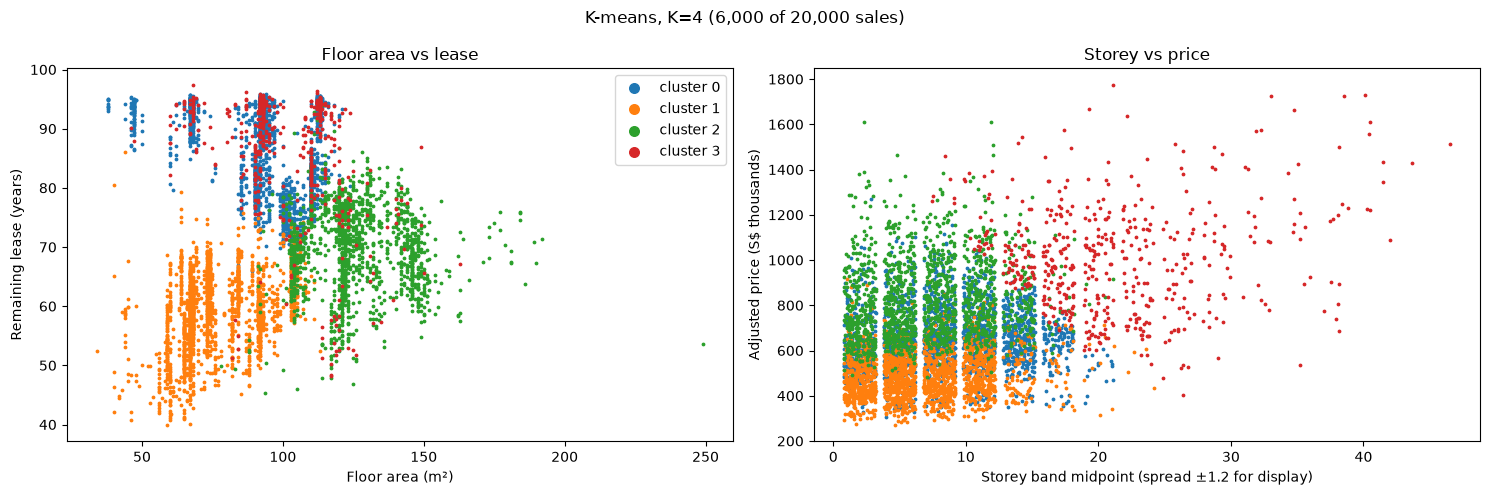

In [11]:
plot_rows = np.random.default_rng(SEED).choice(len(sample), size=6000, replace=False)
palette = plt.get_cmap("tab10")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for cluster in range(K):
    rows_c = plot_rows[kmeans_labels[plot_rows] == cluster]
    part = sample.iloc[rows_c]
    axes[0].scatter(part["floor_area_sqm"], part["remaining_lease_years"], s=3, color=palette(cluster), label=f"cluster {cluster}")
    axes[1].scatter(part["storey_mid"] + np.random.default_rng(cluster).uniform(-1.2, 1.2, len(part)), part["real_price"] / 1000, s=3, color=palette(cluster))
axes[0].set(xlabel="Floor area (m²)", ylabel="Remaining lease (years)", title="Floor area vs lease")
axes[1].set(xlabel="Storey band midpoint (spread ±1.2 for display)", ylabel="Adjusted price (S$ thousands)", title="Storey vs price")
legend = axes[0].legend(markerscale=4)
fig.suptitle(f"K-means, K={K} (6,000 of {SAMPLE_SIZE:,} sales)")
fig.tight_layout()
fig.savefig(FIGURES / "kmeans_clusters.png", dpi=150)

**Observations**

The 4 clusters are market segments, named from their medians:

| Cluster | Share | Median profile | Main flat types | Name |
|---|---|---|---|---|
| 0 | 35.2% | 93 m², 90.3 years left, storey 8, S$632,000 | 4 ROOM 62%, 5 ROOM 22% | Newer mid-size flats |
| 1 | 31.8% | 73 m², 59.6 years left, storey 5, S$469,000 | 3 ROOM 61%, 4 ROOM 37% | Older small flats |
| 2 | 24.5% | 122 m², 69.8 years left, storey 8, S$781,000 | 5 ROOM 53%, EXECUTIVE 28% | Large older flats |
| 3 | 8.5% | 95 m², 89.9 years left, storey 20, S$997,000 | 4 ROOM 52%, 5 ROOM 38% | Newer high-floor flats |

- Lease splits flats of the same size: clusters 0 and 1 overlap in 4 ROOM (62% and 37%), separated by 30 years of lease.
- Storey and price separate cluster 3 from cluster 0 at almost the same size and lease: in the storey vs price plot, cluster 3 holds nearly all sales above storey 20. Its top town is BUKIT MERAH (15%).
- In the floor area vs lease plot the sales form vertical stripes at common floor areas (e.g. 67, 93, 110 m²). Cluster boundaries cut through the continuous lease axis, not through gaps, which matches the weak silhouette.

## 6. DBSCAN: choosing eps and min_samples

k-distance curves with k = `min_samples` in {5, 10, 20} on both versions of the data, with the knee marked (the
point furthest below the straight line from the first to the last value). Then a grid of eps at 0.5, 0.75, 1, 1.5
and 2 times each knee.

knee
data     min_samples       
real     5            0.399
         10           0.567
         20           0.668
jittered 5            0.441
         10           0.529
         20           0.625

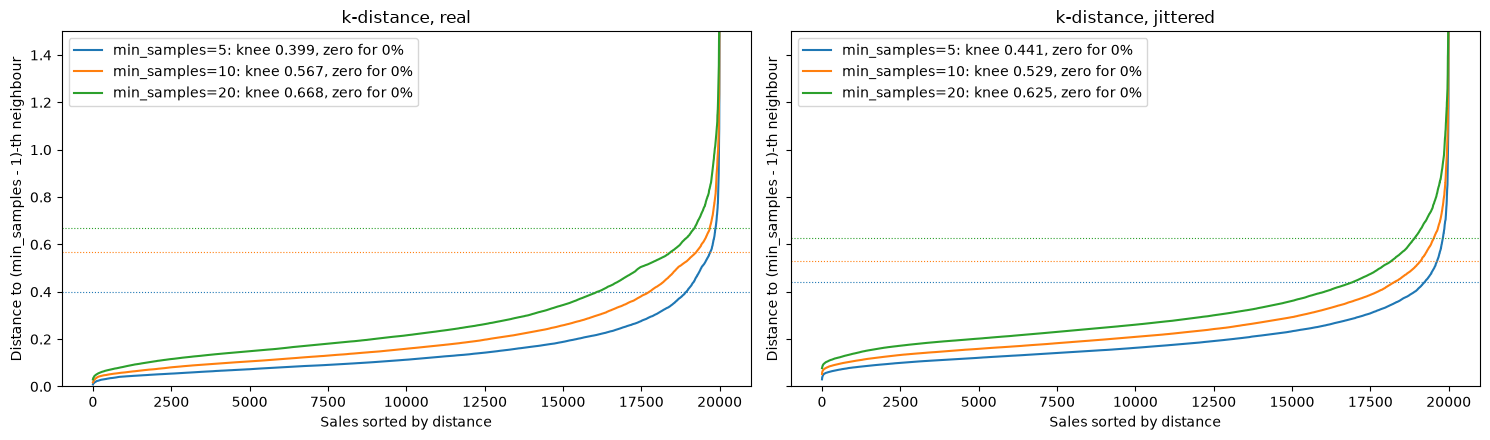

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
knees = {}
for ax, (data_name, data) in zip(axes, DATA.items()):
    for min_samples in (5, 10, 20):
        curve = k_distances(data, min_samples)
        knees[(data_name, min_samples)] = knee = knee_distance(curve)
        line = ax.plot(np.arange(len(curve)), curve, label=f"min_samples={min_samples}: knee {knee:.3f}, zero for {np.mean(curve == 0):.0%}")
        ax.axhline(knee, color=line[0].get_color(), lw=0.8, ls=":")
    ax.set(xlabel="Sales sorted by distance", ylabel="Distance to (min_samples - 1)-th neighbour", title=f"k-distance, {data_name}", ylim=(0, 1.5))
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "dbscan_k_distance.png", dpi=150)
pd.Series(knees, name="knee").rename_axis(["data", "min_samples"]).to_frame()

In [13]:
def density_row(method, data_name, labels, seconds, **setting):
    scores = evaluate(DATA[data_name], labels, truth=flat_type, silhouette_sample=SILHOUETTE_SAMPLE, seed=SEED)
    shares = single_value_share(labels, storey_band)
    return {
        "method": method,
        "data": data_name,
        **setting,
        **scores,
        "single_storey_clusters": int((shares == 1.0).sum()),
        "seconds": seconds,
    }


rows = []
for data_name, data in DATA.items():
    for min_samples in (5, 10, 20):
        for factor in (0.5, 0.75, 1.0, 1.5, 2.0):
            eps = knees[(data_name, min_samples)] * factor
            labels, seconds = timed_fit_predict(dbscan(eps, min_samples), data)
            rows.append(density_row("DBSCAN", data_name, labels, seconds, min_samples=min_samples, eps_factor=factor, eps=eps))
dbscan_grid = pd.DataFrame(rows)
dbscan_grid.to_csv(RESULTS / "dbscan_grid.csv", index=False)
dbscan_grid.drop(columns=["method", "nmi"])

,data,min_samples,eps_factor,eps,n_clusters,noise_fraction,largest_cluster_share,silhouette,davies_bouldin,ari,single_storey_clusters,seconds
0,real,5,0.50,0.200,128,1.672e-01,0.194,-0.314,0.979,2.180e-02,128,0.128
1,real,5,0.75,0.300,96,6.725e-02,0.212,-0.241,1.180,1.619e-02,96,0.174
2,real,5,1.00,0.399,66,3.220e-02,0.216,-0.133,1.564,1.377e-02,66,0.225
3,real,5,1.50,0.599,4,4.150e-03,0.981,0.154,0.671,2.685e-02,0,0.464
4,real,5,2.00,0.799,1,8.500e-04,0.999,NaN,NaN,3.378e-04,0,0.699
5,real,10,0.50,0.284,40,1.409e-01,0.205,-0.171,1.442,1.797e-02,40,0.164
6,real,10,0.75,0.425,43,5.635e-02,0.215,-0.080,1.733,1.457e-02,43,0.241
7,real,10,1.00,0.567,3,1.385e-02,0.971,0.239,0.732,2.965e-02,1,0.425
8,real,10,1.50,0.851,1,1.300e-03,0.999,NaN,NaN,3.807e-04,0,0.773
9,real,10,2.00,1.134,1,2.000e-04,1.000,NaN,NaN,1.680e-04,0,1.288


In [14]:
def choose(grid, data_name):
    rows = grid[grid["data"] == data_name].drop(columns="data")
    best = best_density_setting(rows)
    if best is None:
        print(f"{data_name}: no setting has at least 2 clusters and at most 50% noise")
    return best


dbscan_best = {name: choose(dbscan_grid, name) for name in DATA}
pd.DataFrame({name: row for name, row in dbscan_best.items() if row is not None}).T

,method,min_samples,eps_factor,eps,n_clusters,noise_fraction,largest_cluster_share,silhouette,davies_bouldin,ari,nmi,single_storey_clusters,seconds
real,DBSCAN,10,1.0,0.567,3,0.014,0.971,0.239,0.732,0.03,0.091,1,0.425
jittered,DBSCAN,5,1.5,0.661,2,0.003,0.997,0.494,0.437,0.001,0.001,0,0.513


**Observations**

- The k-distance curves have no plateau followed by a jump: they rise smoothly and turn up only for the last 5% or so of sales. Knees are at 0.399, 0.567 and 0.668 (real) and 0.441, 0.529 and 0.625 (jittered) for `min_samples` 5, 10 and 20.
- **Below the knee, DBSCAN on real data makes many small clusters that are single storey bands:** at 0.5× the knee there are 128 clusters (min_samples 5), all 128 a single storey band; at 0.75× the knee with min_samples 20, 27 of 27. On jittered data the same settings give 89 clusters (49 single bands) and 5 clusters (0).
- **At and above the knee everything merges:** from 1.5× the knee, one cluster holds 98% to 100% of sales on both data versions.
- **The selection rule picks near-single-cluster settings:** real eps 0.567, min_samples 10 gives 3 clusters with 97.1% in one (silhouette 0.239); jittered eps 0.661, min_samples 5 gives 2 clusters with 99.7% in one (silhouette 0.494, the second cluster has 6 sales). The rule (at least 2 clusters, at most 50% noise, highest silhouette) has no limit on the largest cluster, and silhouette rewards one large cluster plus a tiny, distant one.

**Decision:** keep the settings the project rule selects, so the method is compared under the same rule as on the other datasets, and report the rule's failure here as a finding. No DBSCAN setting gives both several clusters and few single-band clusters.

## 7. HDBSCAN: parameter grid

`min_cluster_size` in {100, 200, 400} (scaled from 25 and 50 at 5,000 sales in screening) and `min_samples` in
{None, 5, 10}, on both versions of the data. `None` means `min_samples` equals `min_cluster_size`.

In [15]:
rows = []
for data_name, data in DATA.items():
    for min_cluster_size in (100, 200, 400):
        for min_samples in (None, 5, 10):
            labels, seconds = timed_fit_predict(hdbscan(min_cluster_size, min_samples), data)
            rows.append(density_row("HDBSCAN", data_name, labels, seconds, min_cluster_size=min_cluster_size, min_samples=str(min_samples)))
hdbscan_grid = pd.DataFrame(rows)
hdbscan_grid.to_csv(RESULTS / "hdbscan_grid.csv", index=False)
hdbscan_grid.drop(columns=["method", "nmi"])

,data,min_cluster_size,min_samples,n_clusters,noise_fraction,largest_cluster_share,silhouette,davies_bouldin,ari,single_storey_clusters,seconds
0,real,100,None,14,0.542,0.114,0.043,1.660,1.394e-04,12,1.724
1,real,100,5,41,0.283,0.165,0.005,1.776,2.302e-02,38,1.428
2,real,100,10,32,0.330,0.214,0.006,1.615,3.874e-02,30,1.450
3,real,200,None,2,0.285,0.686,0.160,1.133,7.218e-02,0,2.033
4,real,200,5,12,0.075,0.225,-0.102,3.297,1.178e-02,9,1.421
5,real,200,10,8,0.092,0.214,0.008,3.928,2.195e-02,6,1.441
6,real,400,None,2,0.709,0.206,0.448,0.787,-2.921e-04,0,2.620
7,real,400,5,6,0.110,0.225,0.009,4.970,5.529e-03,6,1.433
8,real,400,10,7,0.107,0.214,0.017,4.284,1.786e-02,6,1.441
9,jittered,100,None,3,0.199,0.757,0.148,1.143,6.513e-02,0,1.707


In [16]:
hdbscan_best = {name: choose(hdbscan_grid, name) for name in DATA}
pd.DataFrame({name: row for name, row in hdbscan_best.items() if row is not None}).T

,method,min_cluster_size,min_samples,n_clusters,noise_fraction,largest_cluster_share,silhouette,davies_bouldin,ari,nmi,single_storey_clusters,seconds
real,HDBSCAN,200,None,2,0.285,0.686,0.16,1.133,0.072,0.101,0,2.033
jittered,HDBSCAN,200,None,2,0.274,0.698,0.15,1.119,0.069,0.096,0,1.989


**Observations**

- **Ties matter at small settings:** real data with `min_cluster_size` 100 gives 14 to 41 clusters, of which 12 to 38 are single storey bands (e.g. 41 clusters, 38 single bands at `min_samples` 5). Jittered data with the same settings gives 3 clusters and no single bands.
- **At `min_cluster_size` 200 with `min_samples` None, real and jittered agree:** 2 clusters, 28.5% vs 27.4% noise, largest cluster 68.6% vs 69.8%.
- With `min_samples` 5 or 10, jittered data puts 90% of sales in one cluster at every size; real data instead splits into 6 to 12 clusters, mostly single storey bands.
- At 400 with `min_samples` None, 70% of sales become noise.
- **Chosen by the rule: `min_cluster_size` 200, `min_samples` None, on both data versions** (silhouette 0.160 real, 0.150 jittered). Runs take about 1.4 to 2.7 s each.

## 8. What the density-based clusters contain

For each chosen setting: cluster sizes, whether a cluster is a single storey band, its main flat type, and how
noise differs from clustered sales.

In [17]:
def refit(method, row, data_name):
    if row is None:
        return None
    if method == "DBSCAN":
        model = dbscan(row["eps"], int(row["min_samples"]))
    else:
        model = hdbscan(int(row["min_cluster_size"]), None if row["min_samples"] == "None" else int(row["min_samples"]))
    return relabel_by_size(model.fit_predict(DATA[data_name]))


density_labels = {
    (method, data_name): refit(method, best[data_name], data_name)
    for method, best in [("DBSCAN", dbscan_best), ("HDBSCAN", hdbscan_best)]
    for data_name in DATA
}
for key, labels in density_labels.items():
    if labels is None:
        continue
    profile = cluster_profiles(labels)
    profile.insert(2, "single storey band", single_value_share(labels, storey_band).reindex(profile.index) == 1.0)
    profile.to_csv(RESULTS / f"density_profiles_{key[0].lower()}_{key[1]}.csv")
    print(key)
    display(profile.head(12))

('DBSCAN', 'real')


,sales,share,single storey band,floor_area_sqm,remaining_lease_years,storey_mid,real_price,top flat_type,top flat_model,top town,top storey_range
cluster,,,,,,,,,,,
-1,277,1.385e-02,False,114.0,75.083,23.0,1.224e+06,5 ROOM (47%),Improved (23%),QUEENSTOWN (16%),22 TO 24 (15%)
0,19416,9.708e-01,False,93.0,72.917,8.0,6.314e+05,4 ROOM (44%),Model A (36%),SENGKANG (8%),04 TO 06 (23%)
1,296,1.480e-02,False,47.0,93.042,8.0,3.738e+05,2 ROOM (100%),Model A (86%),PUNGGOL (16%),10 TO 12 (22%)
2,11,5.500e-04,True,67.0,92.833,38.0,8.385e+05,3 ROOM (100%),Model A (55%),QUEENSTOWN (36%),37 TO 39 (100%)


('DBSCAN', 'jittered')


,sales,share,single storey band,floor_area_sqm,remaining_lease_years,storey_mid,real_price,top flat_type,top flat_model,top town,top storey_range
cluster,,,,,,,,,,,
-1,62,3.100e-03,False,109.0,74.625,26.0,1.091e+06,5 ROOM (37%),Model A (26%),QUEENSTOWN (23%),01 TO 03 (15%)
0,19932,9.966e-01,False,93.0,73.333,8.0,6.303e+05,4 ROOM (43%),Model A (37%),SENGKANG (8%),04 TO 06 (23%)
1,6,3.000e-04,False,92.0,93.333,36.5,7.304e+05,4 ROOM (100%),Model A (100%),JURONG EAST (83%),37 TO 39 (50%)


('HDBSCAN', 'real')


,sales,share,single storey band,floor_area_sqm,remaining_lease_years,storey_mid,real_price,top flat_type,top flat_model,top town,top storey_range
cluster,,,,,,,,,,,
-1,5695,0.285,False,104.0,77.167,11.0,862978.723,4 ROOM (33%),Model A (35%),BUKIT MERAH (11%),10 TO 12 (16%)
0,13727,0.686,False,93.0,70.583,8.0,596470.588,4 ROOM (48%),Model A (35%),SENGKANG (9%),04 TO 06 (27%)
1,578,0.029,False,68.0,93.250,8.0,515981.935,3 ROOM (100%),Model A (85%),PUNGGOL (21%),10 TO 12 (24%)


('HDBSCAN', 'jittered')


,sales,share,single storey band,floor_area_sqm,remaining_lease_years,storey_mid,real_price,top flat_type,top flat_model,top town,top storey_range
cluster,,,,,,,,,,,
-1,5474,0.274,False,104.0,77.917,11.0,866189.336,4 ROOM (33%),Model A (36%),BUKIT MERAH (11%),10 TO 12 (15%)
0,13965,0.698,False,93.0,70.500,8.0,597705.274,4 ROOM (48%),Model A (35%),SENGKANG (9%),04 TO 06 (27%)
1,561,0.028,False,68.0,93.250,8.0,517744.702,3 ROOM (100%),Model A (84%),PUNGGOL (22%),10 TO 12 (25%)


In [18]:
rows = []
for (method, data_name), labels in density_labels.items():
    if labels is None:
        continue
    noise = labels == NOISE_LABEL
    medians = sample[noise].median().add_prefix("noise median ").to_dict() | sample[~noise].median().add_prefix("clustered median ").to_dict()
    type_share = pd.Series(flat_type[noise]).value_counts(normalize=True)
    rows.append({"method": method, "data": data_name, "noise_share": noise.mean(), "noise top flat type": f"{type_share.index[0]} ({type_share.iloc[0]:.0%})" if noise.any() else "", **medians})
noise_contents = pd.DataFrame(rows)
noise_contents.to_csv(RESULTS / "density_noise.csv", index=False)
noise_contents.T

,0,1,2,3
method,DBSCAN,DBSCAN,HDBSCAN,HDBSCAN
data,real,jittered,real,jittered
noise_share,0.014,0.003,0.285,0.274
noise top flat type,5 ROOM (47%),5 ROOM (37%),4 ROOM (33%),4 ROOM (33%)
noise median floor_area_sqm,114.0,109.0,104.0,104.0
noise median remaining_lease_years,75.083,74.625,77.167,77.917
noise median storey_mid,23.0,26.0,11.0,11.0
noise median real_price,1223766.99,1091128.004,862978.723,866189.336
clustered median floor_area_sqm,93.0,93.0,93.0,93.0
clustered median remaining_lease_years,73.333,73.333,71.75,71.5


**Observations**

- **HDBSCAN (real and jittered give the same result):**
  - Cluster 0 is the bulk: 68.6% of sales with median 93 m², 70.6 years left, S$596,000.
  - Cluster 1 is a compact product: 578 sales (2.9%) that are 100% 3 ROOM, median 68 m², 93.25 years left (flats about 6 years into their lease), 85% `Model A`, top town PUNGGOL (21%).
  - Noise (28.5%) is the upper market: median 104 m², storey 11 and S$863,000, against 93 m², storey 8 and S$589,000 for clustered sales.
- **DBSCAN, real:**
  - Besides the bulk (97.1%), it finds 296 sales that are 100% 2 ROOM with 93.0 years left, 86% `Model A`: another compact product.
  - It also finds an 11-sale cluster on one storey band (37 TO 39, 3 ROOM, 36% QUEENSTOWN), which is a tie cluster.
  - Its noise (1.4%) is the top of the market: median storey 23, S$1,224,000.
- **DBSCAN, jittered:** the bulk holds 99.7%; the only other cluster is 6 4 ROOM sales with median storey 36.5, 83% JURONG EAST.
- In every case the density methods treat expensive, high-floor or unusually large flats as noise, because those sales are sparse.

## 9. Method comparison

Each method at its chosen setting, scored on the data version it ran on. The null silhouette runs the same
setting on that data with each column shuffled. K-means runs use seed 0 and `n_init=1`, as in section 3.

In [19]:
def null_scores(model, data):
    null = shuffled_null(data, np.random.default_rng(SEED))
    labels = model.fit_predict(null)
    return evaluate(null, labels, silhouette_sample=SILHOUETTE_SAMPLE, seed=SEED)


setups = [
    ("K-means (random)", "real", kmeans_random(K, SEED), f"K={K}"),
    ("K-means++", "real", kmeans_plus_plus(K, SEED), f"K={K}"),
]
for method, best, factory in [("DBSCAN", dbscan_best, None), ("HDBSCAN", hdbscan_best, None)]:
    for data_name in DATA:
        row = best[data_name]
        if row is None:
            continue
        if method == "DBSCAN":
            setups.append((method, data_name, dbscan(row["eps"], int(row["min_samples"])), f"eps={row['eps']:.3f}, min_samples={int(row['min_samples'])}"))
        else:
            min_samples = None if row["min_samples"] == "None" else int(row["min_samples"])
            setups.append((method, data_name, hdbscan(int(row["min_cluster_size"]), min_samples), f"min_cluster_size={int(row['min_cluster_size'])}, min_samples={min_samples}"))

rows, comparison_labels = [], {}
for method, data_name, model, setting in setups:
    labels, seconds = timed_fit_predict(model, DATA[data_name])
    comparison_labels[f"{method}, {data_name}"] = labels
    scores = evaluate(DATA[data_name], labels, truth=flat_type, silhouette_sample=SILHOUETTE_SAMPLE, seed=SEED)
    null = null_scores(model, DATA[data_name])
    rows.append(
        {
            "method": method,
            "data": data_name,
            "setting": setting,
            **scores,
            "null_silhouette": null["silhouette"],
            "null_n_clusters": null["n_clusters"],
            "null_noise_fraction": null["noise_fraction"],
            "single_storey_clusters": int((single_value_share(labels, storey_band) == 1.0).sum()),
            "seconds": seconds,
        }
    )
area_labels = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit_predict(area_only)
comparison = pd.DataFrame(rows)
comparison.to_csv(RESULTS / "comparison.csv", index=False)
print(f"floor-area baseline, K={K}: ARI vs flat type {adjusted_rand_score(flat_type, area_labels):.3f}")
comparison

floor-area baseline, K=4: ARI vs flat type 0.649


,method,data,setting,n_clusters,noise_fraction,largest_cluster_share,silhouette,davies_bouldin,ari,nmi,null_silhouette,null_n_clusters,null_noise_fraction,single_storey_clusters,seconds
0,K-means (random),real,K=4,4,0.000,0.362,0.317,1.116,0.220,0.299,0.195,4,0.000,0,0.011
1,K-means++,real,K=4,4,0.000,0.351,0.317,1.116,0.213,0.293,0.218,4,0.000,0,0.010
2,DBSCAN,real,"eps=0.567, min_samples=10",3,0.014,0.971,0.239,0.732,0.030,0.091,0.330,2,0.052,1,0.428
3,DBSCAN,jittered,"eps=0.661, min_samples=5",2,0.003,0.997,0.494,0.437,0.001,0.001,0.289,6,0.015,0,0.517
4,HDBSCAN,real,"min_cluster_size=200, min_samples=None",2,0.285,0.686,0.160,1.133,0.072,0.101,0.593,2,0.940,0,2.022
5,HDBSCAN,jittered,"min_cluster_size=200, min_samples=None",2,0.274,0.698,0.150,1.119,0.069,0.096,0.565,2,0.924,0,1.984


In [20]:
names = list(comparison_labels)
agreement = pd.DataFrame(
    [[adjusted_rand_score(comparison_labels[a], comparison_labels[b]) for b in names] for a in names], index=names, columns=names
)
agreement.to_csv(RESULTS / "agreement.csv")
agreement.round(3)

,"K-means (random), real","K-means++, real","DBSCAN, real","DBSCAN, jittered","HDBSCAN, real","HDBSCAN, jittered"
"K-means (random), real",1.000,0.933,0.008,0.003,0.116,0.115
"K-means++, real",0.933,1.000,0.008,0.003,0.109,0.108
"DBSCAN, real",0.008,0.008,1.000,0.197,0.072,0.079
"DBSCAN, jittered",0.003,0.003,0.197,1.000,0.008,0.009
"HDBSCAN, real",0.116,0.109,0.072,0.008,1.000,0.886
"HDBSCAN, jittered",0.115,0.108,0.079,0.009,0.886,1.000


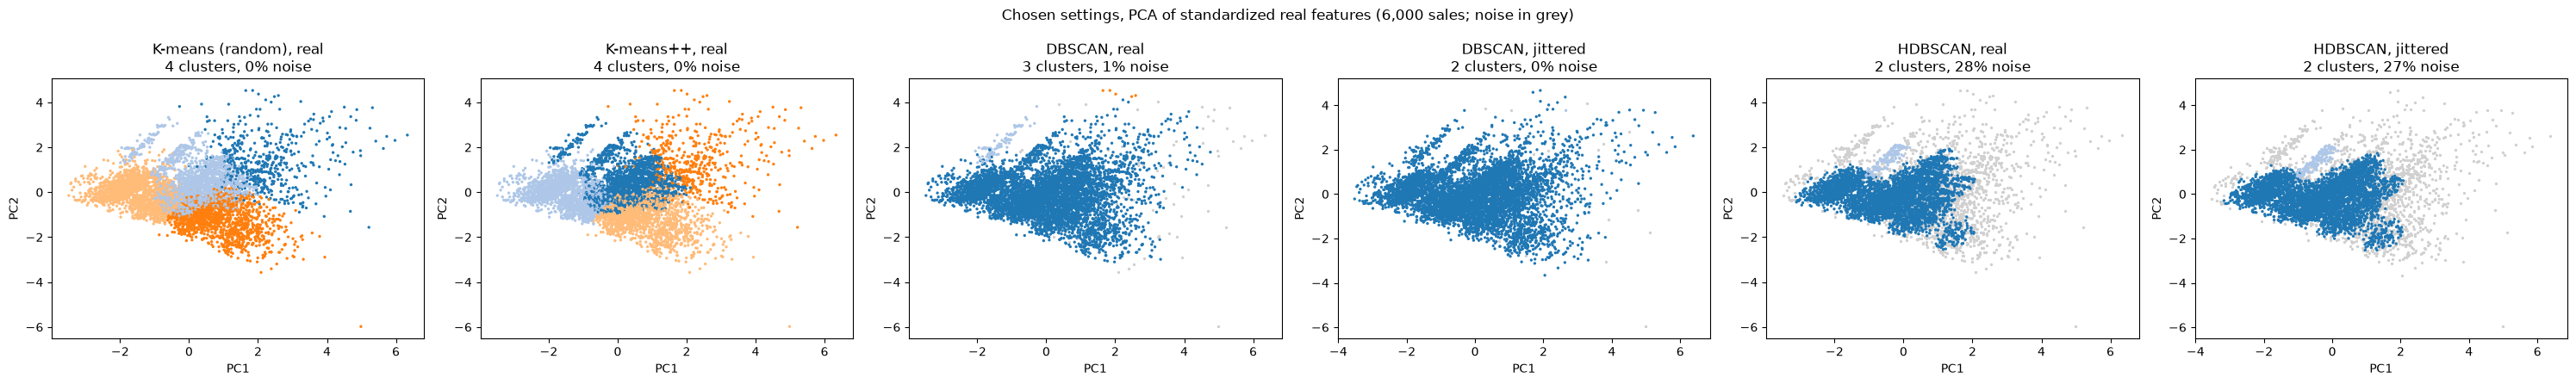

In [21]:
pca = PCA(n_components=2).fit(X)
shown = [name for name in names if name != "K-means (random)"]
fig, axes = plt.subplots(1, len(shown), figsize=(5 * len(shown), 4.5), squeeze=False)
colours = plt.get_cmap("tab20")
for ax, name in zip(axes[0], shown):
    data_name = name.split(", ")[1]
    points = pca.transform(DATA[data_name])[plot_rows]
    labels = comparison_labels[name][plot_rows]
    noise = labels == NOISE_LABEL
    ax.scatter(points[noise, 0], points[noise, 1], s=2, color="#d0d0d0")
    ax.scatter(points[~noise, 0], points[~noise, 1], s=2, c=[colours(label % 20) for label in labels[~noise]])
    row = comparison.iloc[names.index(name)]
    ax.set(xlabel="PC1", ylabel="PC2", title=f"{name}\n{int(row['n_clusters'])} clusters, {row['noise_fraction']:.0%} noise")
fig.suptitle("Chosen settings, PCA of standardized real features (6,000 sales; noise in grey)")
fig.tight_layout()
fig.savefig(FIGURES / "comparison.png", dpi=150)

**Observations**

| Method (data) | Clusters | Noise | Largest | Silhouette (null) | ARI flat type | Runtime |
|---|---|---|---|---|---|---|
| K-means random (real) | 4 | 0% | 36.2% | 0.317 (0.195) | 0.220 | about 0.01 s |
| K-means++ (real) | 4 | 0% | 35.1% | 0.317 (0.218) | 0.213 | about 0.01 s |
| DBSCAN (real) | 3 | 1.4% | 97.1% | 0.239 (0.330) | 0.030 | about 0.4 s |
| DBSCAN (jittered) | 2 | 0.3% | 99.7% | 0.494 (0.289) | 0.001 | about 0.5 s |
| HDBSCAN (real) | 2 | 28.5% | 68.6% | 0.160 (0.593) | 0.072 | about 2 s |
| HDBSCAN (jittered) | 2 | 27.4% | 69.8% | 0.150 (0.565) | 0.069 | about 2 s |

- **Only K-means beats its null on silhouette** (0.317 vs 0.195 to 0.218). DBSCAN on real data and HDBSCAN score below theirs. HDBSCAN's null silhouette of 0.593 comes from a null run that leaves 94.0% of sales as noise, so it scores a small remainder. DBSCAN jittered beats its null only because its second cluster has 6 sales.
- HDBSCAN does separate real data from the null by noise: 28.5% vs 94.0%. There is density structure, but it is one dense core and a sparse upper market, not several groups.
- The floor-area baseline (K=4) matches flat type with ARI 0.649, far above every method (at most 0.220).
- **Agreement:**
  - K-means random and K-means++ agree with ARI 0.933.
  - HDBSCAN real and jittered agree with ARI 0.886; DBSCAN real and jittered agree only 0.197 (their small clusters differ).
  - K-means and density methods barely agree (ARI 0.003 to 0.116): they answer different questions, segments of a continuum against a dense core with outliers.

## 10. Summary

| Question | Evidence | Answer |
|---|---|---|
| Is there partition structure? | K-means silhouette 0.317 at K=4 vs null 0.219 (1.45x); flat objective near the optimum | Weak but real: 4 interpretable segments (newer mid-size, older small, large older, newer high-floor) |
| Does initialization matter? | All 40 runs within 0.009% of the best inertia; seed ARI 0.93 to 1.00 | No, at K=4 on this data |
| Does K-means recover flat type? | ARI at most 0.256; floor area alone 0.649 | No: flat type is a floor-area rule, and lease and storey cut across it |
| Does scale matter? | Raw units: silhouette 0.540 but ARI 0.261 with the standardized partition (price bands) | Yes: standardizing changes which clusters are found |
| Do ties create false density clusters? | Real data at small settings: 128 of 128 (DBSCAN) and 38 of 41 (HDBSCAN) clusters are single storey bands; jittered data at the same settings mostly does not produce them | Yes, at fine settings. At the chosen HDBSCAN setting, real and jittered agree (ARI 0.886) |
| Is there density structure? | HDBSCAN noise 28.5% vs 94.0% on the null; clusters: a 68.6% core and a 578-sale block of new 3 ROOM flats | One dense core, a few compact product types (new 2 ROOM and 3 ROOM), and a sparse upper market labelled noise |
| Does the project's density selection rule work? | Chosen DBSCAN settings put 97.1% and 99.7% of sales in one cluster; DBSCAN real and HDBSCAN silhouettes are below their nulls | No: without a cap on the largest cluster, it rewards one giant cluster plus a tiny one. Stage 4 should test a largest-cluster cap |

**Report role, as tested so far:** real data with labels where metrics mislead in three ways: silhouette rewards raw price bands and giant-plus-tiny density partitions; ties produce single-band clusters at fine density settings; and ARI against flat type measures floor area. K-means gives the useful result (market segments); density methods find only a core, small product clusters and the upper market as noise.

**For Stage 4:** a largest-cluster cap in the density selection rule; feature-set ablation (without lease, plus price per m²); raw vs standardized across all methods; subsample stability and scalability up to all 234,294 sales.